In [1]:
import pandas as pd

# Load the uploaded dataset
file_path = 'Updated_Employee_Attrition_Data.csv'
df = pd.read_csv(file_path)

# Get basic information
dataset_shape = df.shape
column_info = df.dtypes
null_values = df.isnull().sum()
first_five_rows = df.head()

dataset_shape, column_info, null_values, first_five_rows


((23000, 36),
 Age                          int64
 Attrition                   object
 BusinessTravel              object
 DailyRate                    int64
 Department                  object
 DistanceFromHome             int64
 Education                    int64
 EducationField              object
 EmployeeCount                int64
 EmployeeNumber               int64
 EnvironmentSatisfaction      int64
 Gender                      object
 HourlyRate                   int64
 JobInvolvement               int64
 JobLevel                     int64
 JobRole                     object
 JobSatisfaction              int64
 MaritalStatus               object
 MonthlyIncome                int64
 MonthlyRate                  int64
 NumCompaniesWorked           int64
 Over18                      object
 OverTime                    object
 PercentSalaryHike            int64
 PerformanceRating            int64
 RelationshipSatisfaction     int64
 StandardHours                int64
 StockOptionLe

In [2]:
print("Dataset Shape:", df.shape)
print("Missing Values:\n", df.isnull().sum())
print("Unique Values per Column:\n", df.nunique())

Dataset Shape: (23000, 36)
Missing Values:
 Age                             0
Attrition                       0
BusinessTravel                  0
DailyRate                       0
Department                      0
DistanceFromHome                0
Education                       0
EducationField                  0
EmployeeCount                   0
EmployeeNumber                  0
EnvironmentSatisfaction         0
Gender                          0
HourlyRate                      0
JobInvolvement                  0
JobLevel                        0
JobRole                         0
JobSatisfaction                 0
MaritalStatus                   0
MonthlyIncome                   0
MonthlyRate                     0
NumCompaniesWorked              0
Over18                          0
OverTime                        0
PercentSalaryHike               0
PerformanceRating               0
RelationshipSatisfaction        0
StandardHours                   0
StockOptionLevel                0
Tota

<ipython-input-3-a18e0c033881>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='Attrition', palette='viridis')


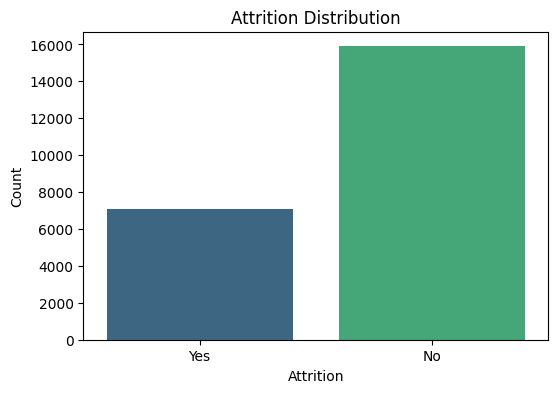

,count
Attrition,
No,15893
Yes,7107


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Drop the 'Name' column
df_cleaned = df.drop(columns=['Name'])

# Step 2: Basic Attrition visualization
attrition_counts = df_cleaned['Attrition'].value_counts()

# Plot Attrition distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df_cleaned, x='Attrition', palette='viridis')
plt.title('Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

attrition_counts


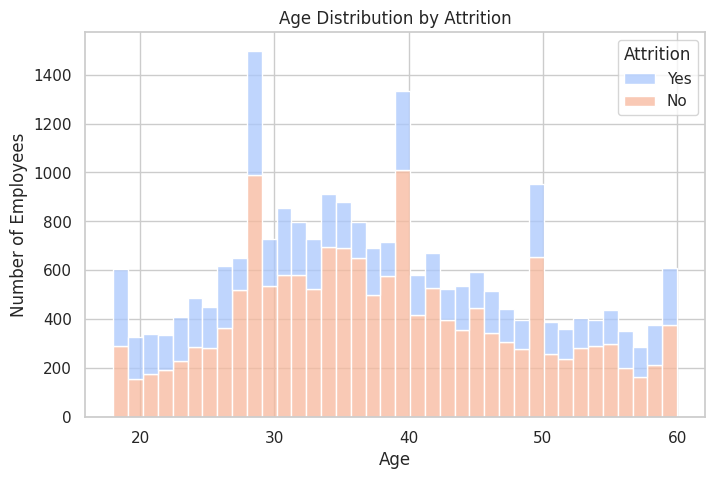

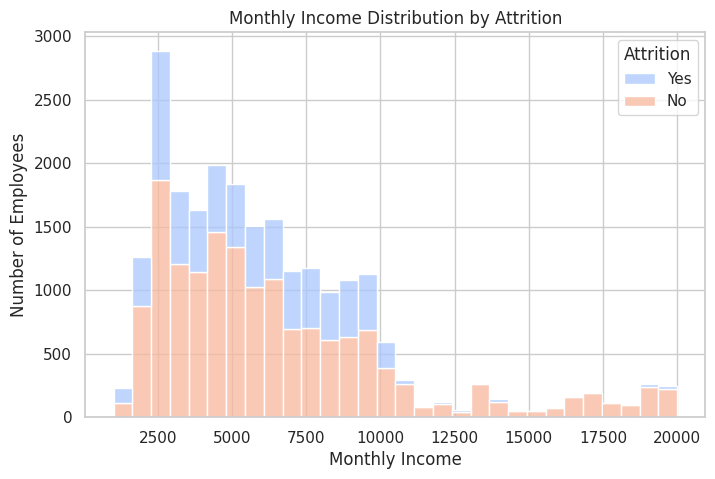

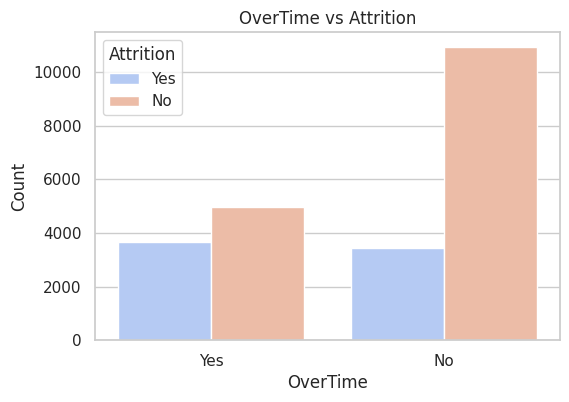

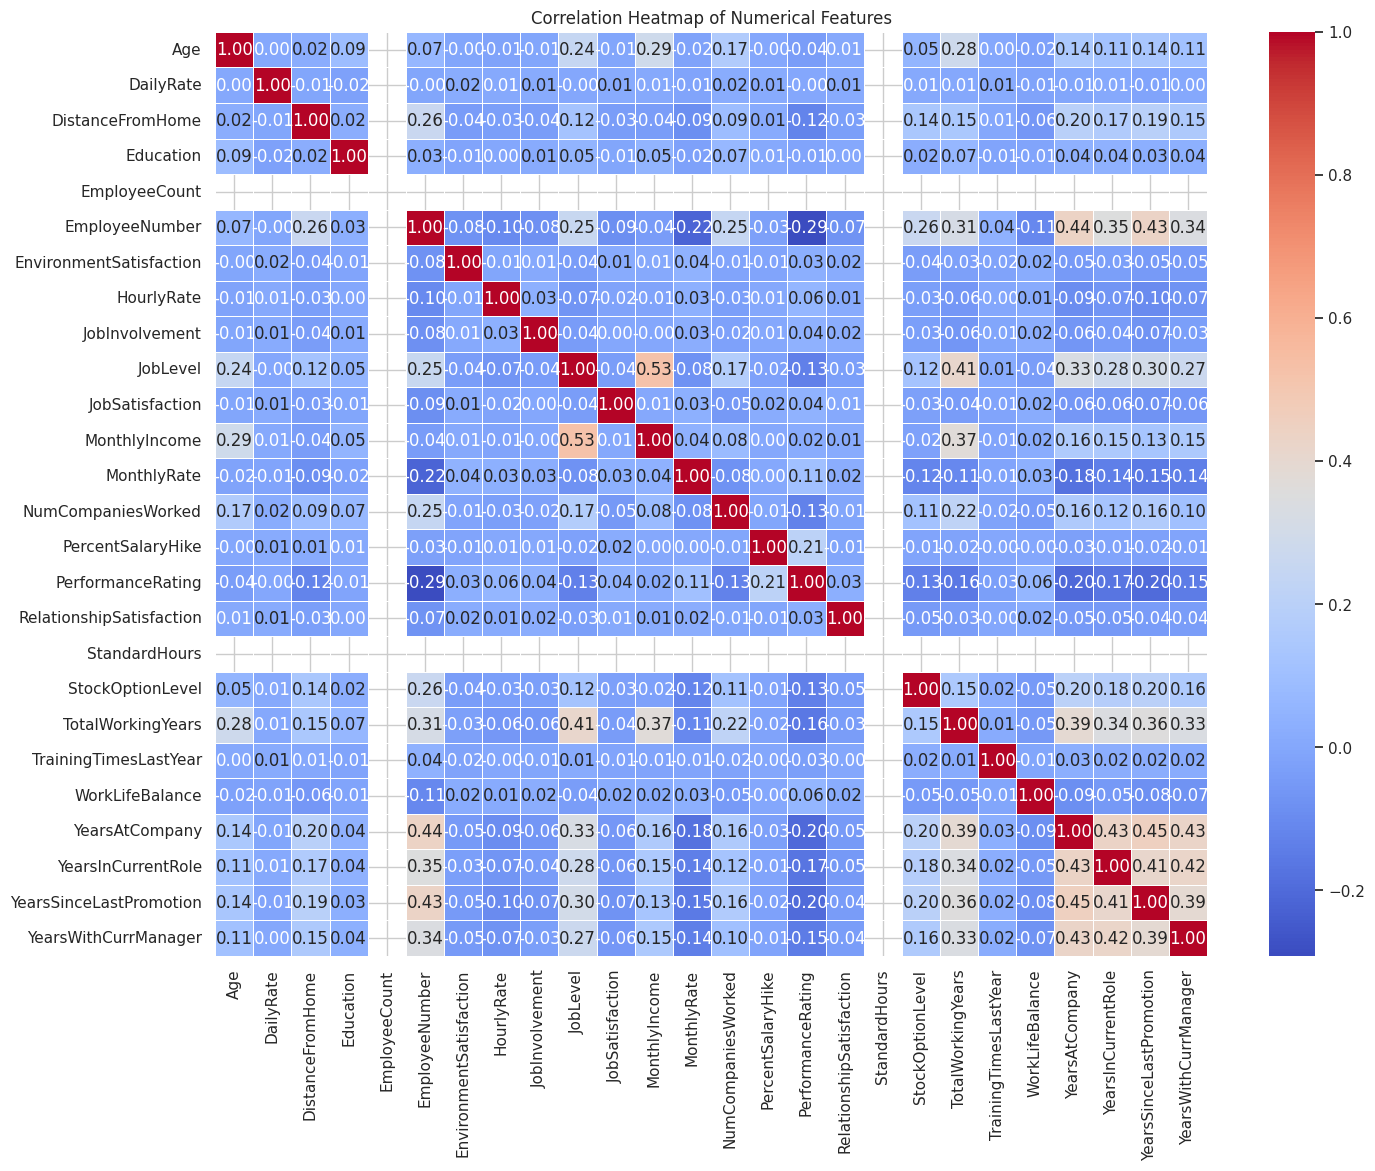

In [4]:
# Visualizations: Important features vs Attrition

# Set the style
sns.set(style="whitegrid")

# Plot 1: Age vs Attrition
plt.figure(figsize=(8, 5))
sns.histplot(data=df_cleaned, x='Age', hue='Attrition', multiple='stack', palette='coolwarm')
plt.title('Age Distribution by Attrition')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.show()

# Plot 2: MonthlyIncome vs Attrition
plt.figure(figsize=(8, 5))
sns.histplot(data=df_cleaned, x='MonthlyIncome', hue='Attrition', multiple='stack', palette='coolwarm', bins=30)
plt.title('Monthly Income Distribution by Attrition')
plt.xlabel('Monthly Income')
plt.ylabel('Number of Employees')
plt.show()

# Plot 3: OverTime vs Attrition
plt.figure(figsize=(6, 4))
sns.countplot(data=df_cleaned, x='OverTime', hue='Attrition', palette='coolwarm')
plt.title('OverTime vs Attrition')
plt.xlabel('OverTime')
plt.ylabel('Count')
plt.show()

# Correlation heatmap for numerical features
plt.figure(figsize=(16, 12))
numerical_features = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df_cleaned[numerical_features].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


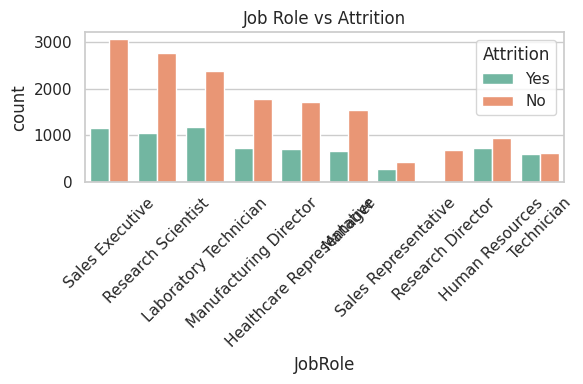

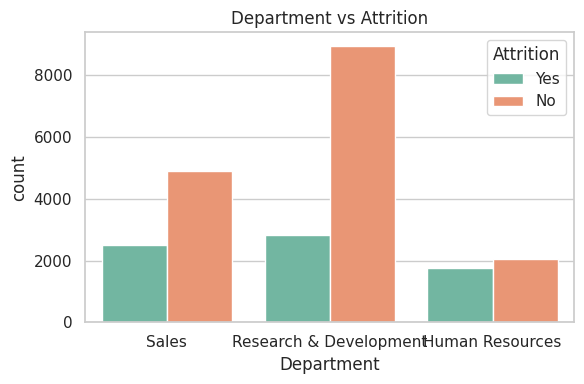

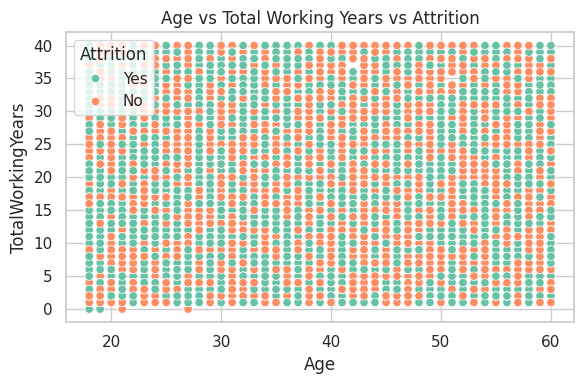

<ipython-input-5-c55bb9faa04e>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='JobSatisfaction', y='MonthlyIncome', data=df, palette='Set3')


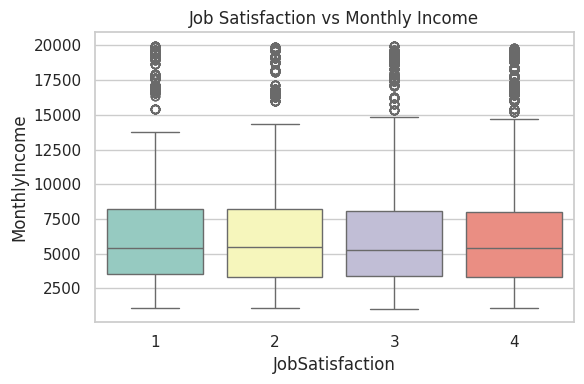

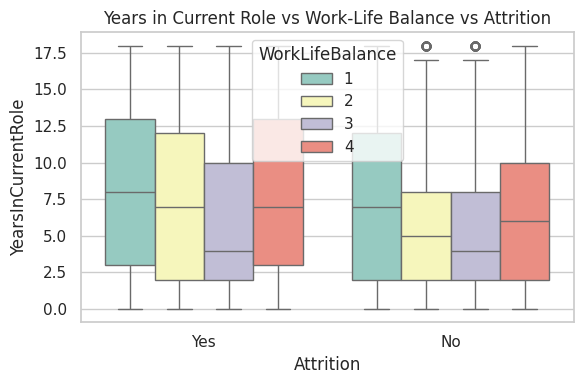

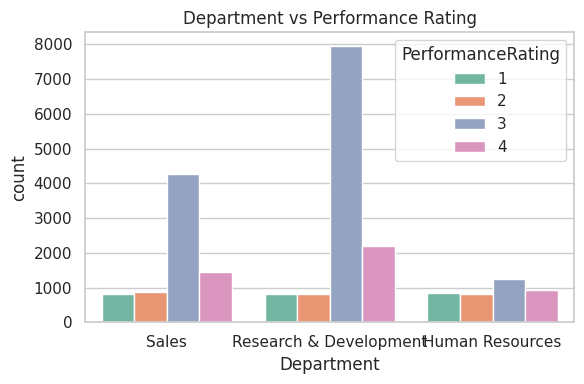

In [5]:

# Investigate Attrition vs Various Categorical Features
plt.figure(figsize=(6, 4))
sns.countplot(x='JobRole', hue='Attrition', data=df, palette='Set2')
plt.title("Job Role vs Attrition")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Investigate Attrition vs Department
plt.figure(figsize=(6, 4))
sns.countplot(x='Department', hue='Attrition', data=df, palette='Set2')
plt.title("Department vs Attrition")
plt.tight_layout()
plt.show()

# Investigate Age and Experience vs Attrition
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Age', y='TotalWorkingYears', hue='Attrition', data=df, palette='Set2')
plt.title("Age vs Total Working Years vs Attrition")
plt.tight_layout()
plt.show()

# Investigate Job Satisfaction vs Monthly Income
plt.figure(figsize=(6, 4))
sns.boxplot(x='JobSatisfaction', y='MonthlyIncome', data=df, palette='Set3')
plt.title("Job Satisfaction vs Monthly Income")
plt.tight_layout()
plt.show()

# Investigate Years in Current Role vs Work-Life Balance vs Attrition
plt.figure(figsize=(6, 4))
sns.boxplot(x='Attrition', y='YearsInCurrentRole', hue='WorkLifeBalance', data=df, palette='Set3')
plt.title("Years in Current Role vs Work-Life Balance vs Attrition")
plt.tight_layout()
plt.show()

# Investigate Department vs Performance Rating
plt.figure(figsize=(6, 4))
sns.countplot(x='Department', hue='PerformanceRating', data=df, palette='Set2')
plt.title("Department vs Performance Rating")
plt.tight_layout()
plt.show()


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer # Import SimpleImputer

# Step 1: Encode categorical features
df_encoded = df_cleaned.copy()

# Identify categorical columns
categorical_cols = df_encoded.select_dtypes(include=['object']).columns

# Apply Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Step 2: Define features (X) and target (y)
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Get feature names before transformation
feature_names_original = X.columns # Add this line to get feature names

# Step 3: Impute missing values using SimpleImputer
imputer = SimpleImputer(strategy='most_frequent') # Create an imputer object
X = imputer.fit_transform(X) # Fit and transform the imputer on X

# Step 4: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18400, 34), (4600, 34), (18400,), (4600,))

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Step 2: Predict on Test Set
y_pred_logreg = log_reg.predict(X_test)

# Step 3: Evaluate the model
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
conf_matrix_logreg = confusion_matrix(y_test, y_pred_logreg)
class_report_logreg = classification_report(y_test, y_pred_logreg)

accuracy_logreg, conf_matrix_logreg, class_report_logreg


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


(0.6910869565217391,
 array([[2794,  385],
        [1036,  385]]),
 '              precision    recall  f1-score   support\n\n           0       0.73      0.88      0.80      3179\n           1       0.50      0.27      0.35      1421\n\n    accuracy                           0.69      4600\n   macro avg       0.61      0.57      0.57      4600\nweighted avg       0.66      0.69      0.66      4600\n')

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Step 1: Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Step 2: Predict on Test Set
y_pred_rf = rf_clf.predict(X_test)

# Step 3: Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(accuracy_rf),
print(conf_matrix_rf), print(class_report_rf)


0.7865217391304348
[[2722  457]
 [ 525  896]]
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      3179
           1       0.66      0.63      0.65      1421

    accuracy                           0.79      4600
   macro avg       0.75      0.74      0.75      4600
weighted avg       0.78      0.79      0.79      4600



(None, None)

In [9]:
pip install plotly


In [10]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE after train-test split
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {X_train.shape}, {y_train.value_counts()}")
print(f"After SMOTE: {X_train_resampled.shape}, {y_train_resampled.value_counts()}")


Before SMOTE: (18400, 34), Attrition
0    12714
1     5686
Name: count, dtype: int64
After SMOTE: (25428, 34), Attrition
1    12714
0    12714
Name: count, dtype: int64


(23000, 36)
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWor

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.6379 - loss: 0.6420 - val_accuracy: 0.7239 - val_loss: 0.7135
Epoch 2/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7107 - loss: 0.5284 - val_accuracy: 0.8242 - val_loss: 0.6610
Epoch 3/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7289 - loss: 0.5043 - val_accuracy: 0.8500 - val_loss: 0.6595
Epoch 4/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7433 - loss: 0.4814 - val_accuracy: 0.8887 - val_loss: 0.5964
Epoch 5/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7466 - loss: 0.4665 - val_accuracy: 0.9101 - val_loss: 0.5657
Epoch 6/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7528 - loss: 0.4514 - val_accuracy: 0.9398 - val_loss: 0.5312
Epoch 7/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7600 - loss: 0.4405 - val_accuracy: 0.9583 - val_loss: 0.5073
Epoch 8/30
636/636 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7662 - loss: 0.4253 - val_accuracy: 0

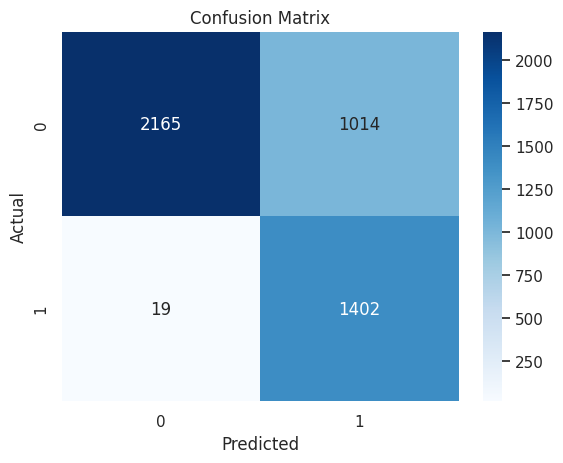

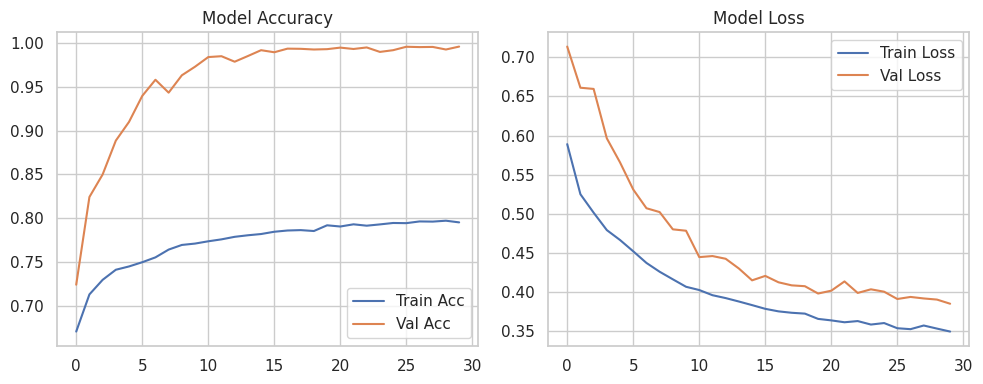

In [11]:
# 📘 Updated Notebook: Employee Attrition Analysis with Deep Learning

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 2. Load Dataset
file_path = 'Updated_Employee_Attrition_Data.csv'
df = pd.read_csv(file_path)

# 3. Data Overview
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

# 4. Preprocessing
# Drop identifier column
df = df.drop(columns=['Name'])

# Encode target and binary features
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])
df['OverTime'] = le.fit_transform(df['OverTime'])

# Check for missing values
print("\nMissing Value Summary:")
print(df.isnull().sum())

# Fill or drop missing values (example: median fill)
df = df.fillna(df.median(numeric_only=True))

# Feature and Target Split
X = df.drop(columns=['Attrition'])
y = df['Attrition']

# One-Hot Encode Categorical Features
X = pd.get_dummies(X,
                  columns=['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18'],
                  drop_first=True)  # Optional: drop_first to avoid multicollinearity

# Train-Test Split (after one-hot encoding)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# 5. Deep Learning Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_bal.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train_bal, y_train_bal, validation_split=0.2, epochs=30, batch_size=32, verbose=1)

# 6. Evaluation
loss, accuracy = model.evaluate(X_test_scaled, y_test)
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nTest Accuracy:", accuracy)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 7. Plot Training History
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()


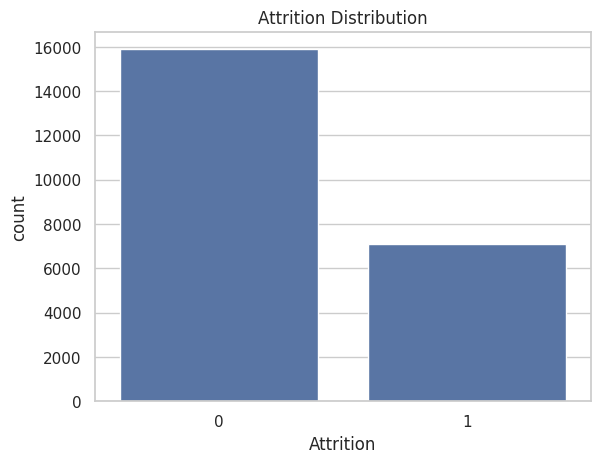

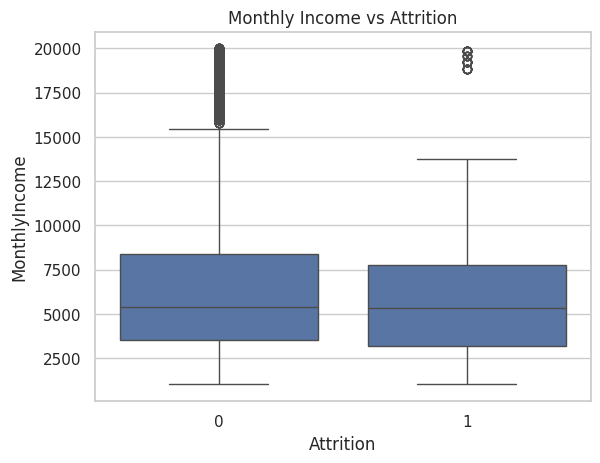

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Attrition count plot
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()


# Boxplot of numerical features vs Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.show()


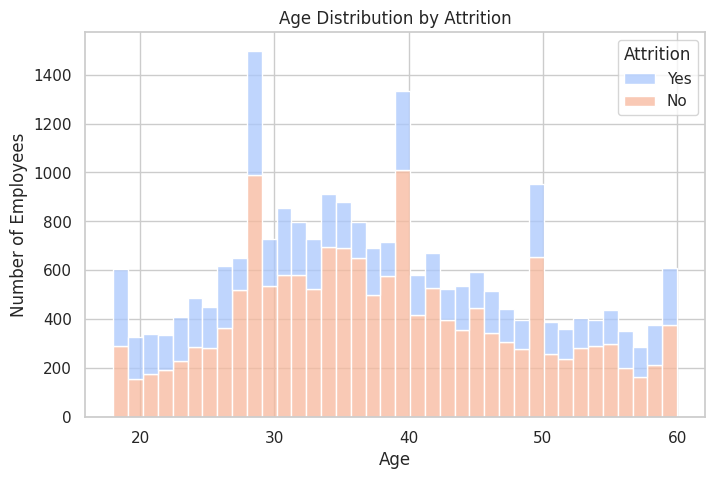

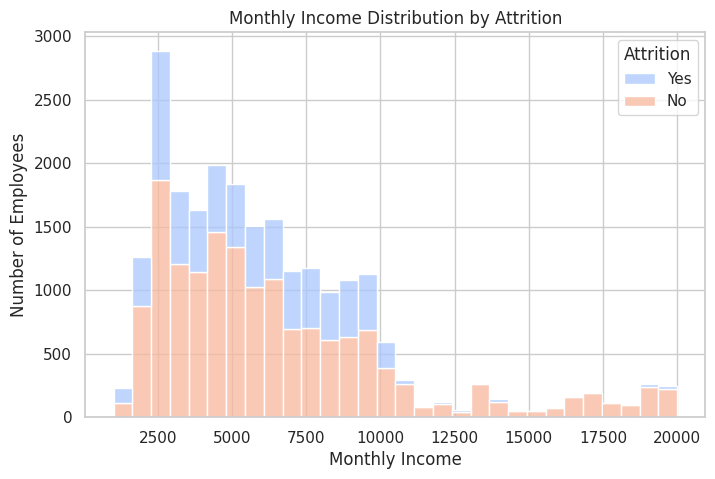

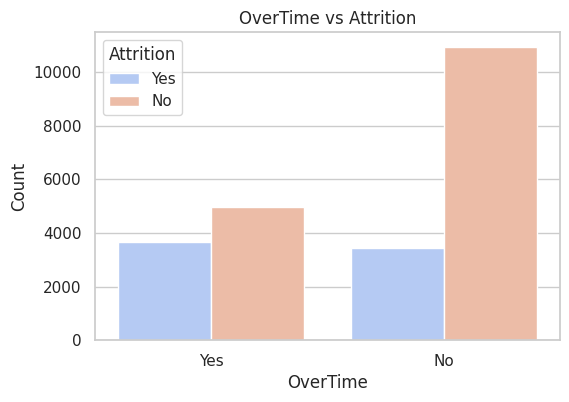

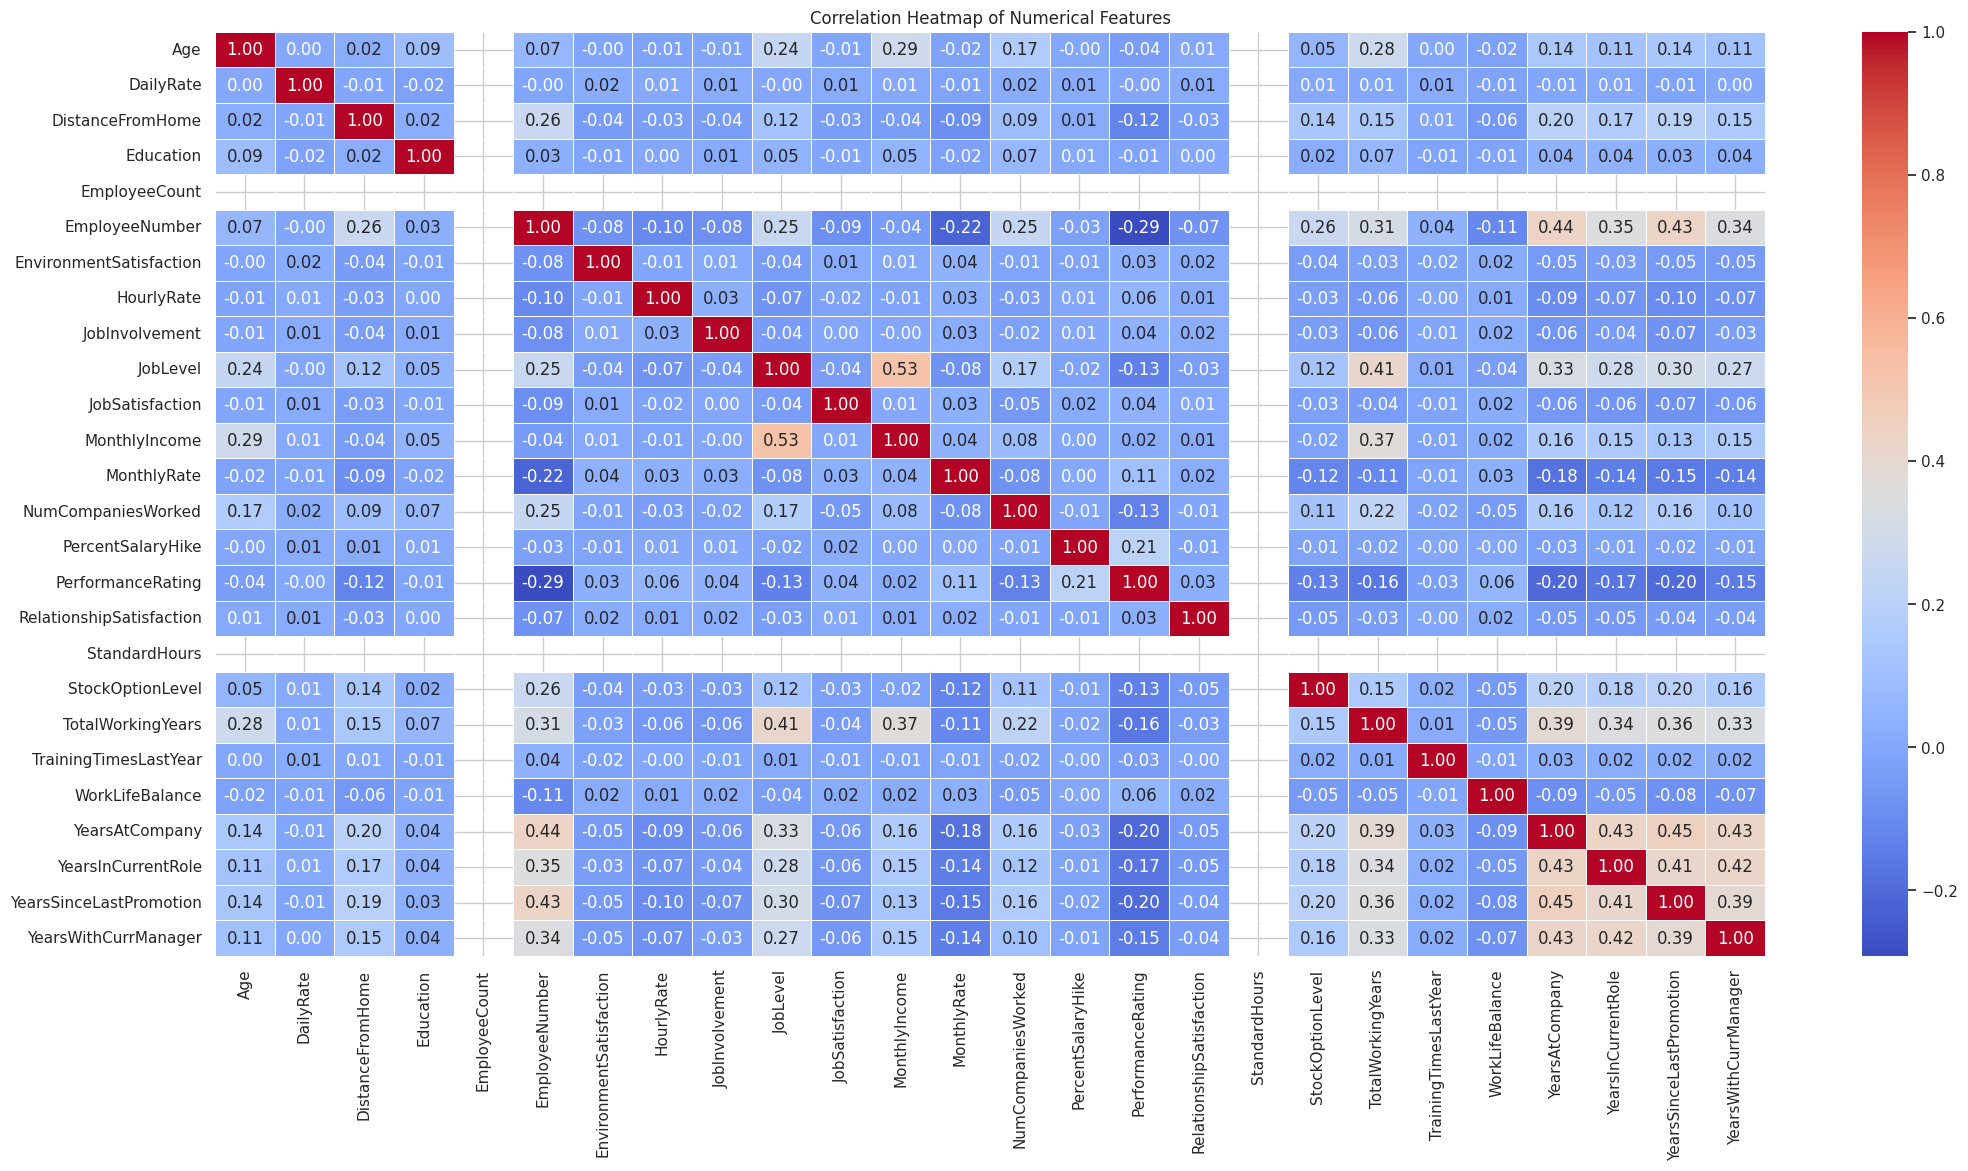

In [13]:
# Visualizations: Important features vs Attrition

# Set the style
sns.set(style="whitegrid")

# Plot 1: Age vs Attrition
plt.figure(figsize=(8, 5))
sns.histplot(data=df_cleaned, x='Age', hue='Attrition', multiple='stack', palette='coolwarm')
plt.title('Age Distribution by Attrition')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.show()

# Plot 2: MonthlyIncome vs Attrition
plt.figure(figsize=(8, 5))
sns.histplot(data=df_cleaned, x='MonthlyIncome', hue='Attrition', multiple='stack', palette='coolwarm', bins=30)
plt.title('Monthly Income Distribution by Attrition')
plt.xlabel('Monthly Income')
plt.ylabel('Number of Employees')
plt.show()

# Plot 3: OverTime vs Attrition
plt.figure(figsize=(6, 4))
sns.countplot(data=df_cleaned, x='OverTime', hue='Attrition', palette='coolwarm')
plt.title('OverTime vs Attrition')
plt.xlabel('OverTime')
plt.ylabel('Count')
plt.show()

# Correlation heatmap for numerical features
plt.figure(figsize=(25, 12))
numerical_features = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df_cleaned[numerical_features].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


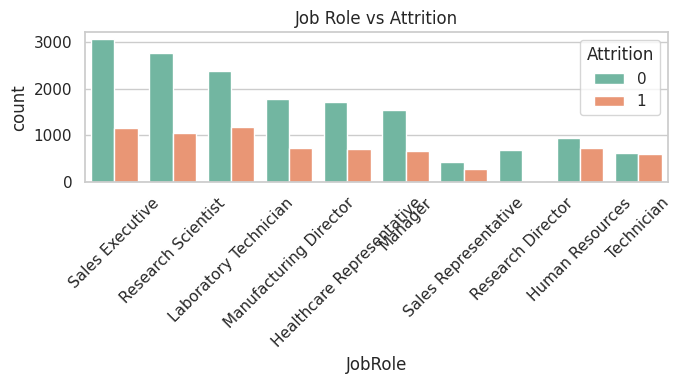

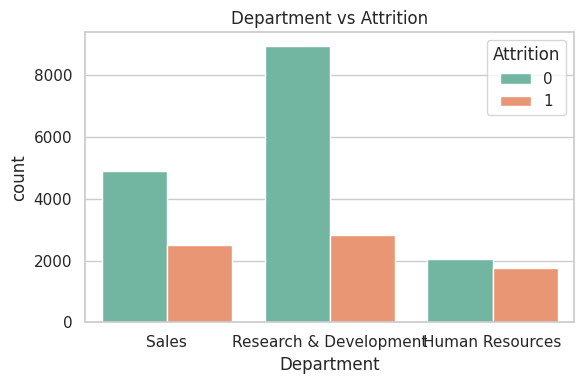

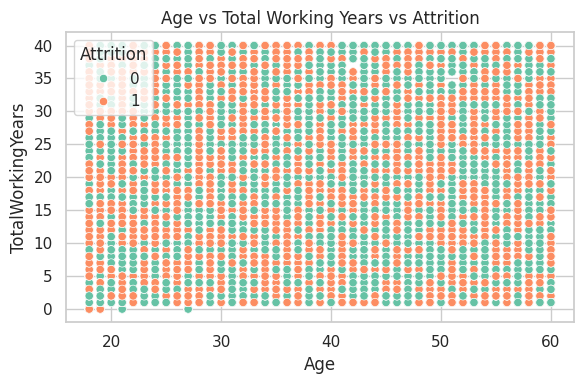

<ipython-input-14-4c8b3a8894ab>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='JobSatisfaction', y='MonthlyIncome', data=df, palette='Set3')


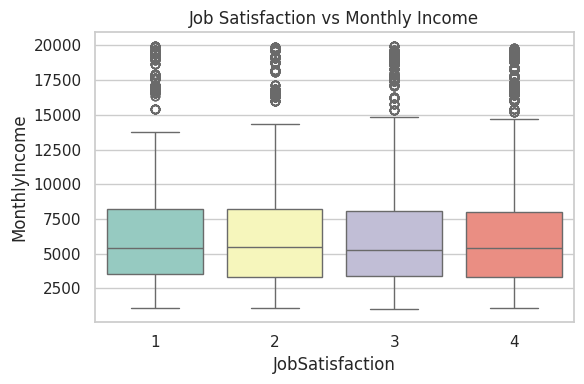

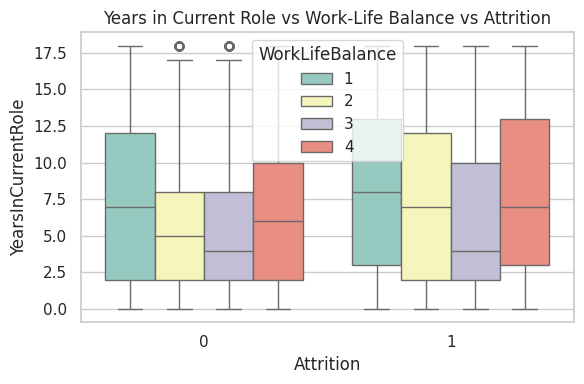

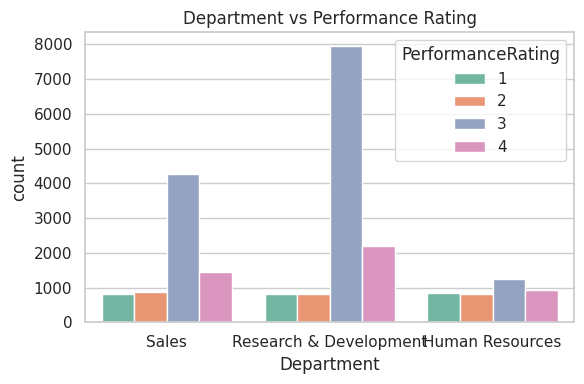

In [14]:

# Investigate Attrition vs Various Categorical Features
plt.figure(figsize=(7, 4))
sns.countplot(x='JobRole', hue='Attrition', data=df, palette='Set2')
plt.title("Job Role vs Attrition")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Investigate Attrition vs Department
plt.figure(figsize=(6, 4))
sns.countplot(x='Department', hue='Attrition', data=df, palette='Set2')
plt.title("Department vs Attrition")
plt.tight_layout()
plt.show()

# Investigate Age and Experience vs Attrition
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Age', y='TotalWorkingYears', hue='Attrition', data=df, palette='Set2')
plt.title("Age vs Total Working Years vs Attrition")
plt.tight_layout()
plt.show()

# Investigate Job Satisfaction vs Monthly Income
plt.figure(figsize=(6, 4))
sns.boxplot(x='JobSatisfaction', y='MonthlyIncome', data=df, palette='Set3')
plt.title("Job Satisfaction vs Monthly Income")
plt.tight_layout()
plt.show()

# Investigate Years in Current Role vs Work-Life Balance vs Attrition
plt.figure(figsize=(6, 4))
sns.boxplot(x='Attrition', y='YearsInCurrentRole', hue='WorkLifeBalance', data=df, palette='Set3')
plt.title("Years in Current Role vs Work-Life Balance vs Attrition")
plt.tight_layout()
plt.show()

# Investigate Department vs Performance Rating
plt.figure(figsize=(6, 4))
sns.countplot(x='Department', hue='PerformanceRating', data=df, palette='Set2')
plt.title("Department vs Performance Rating")
plt.tight_layout()
plt.show()


In [15]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Hyperparameter distribution for Random Forest
param_dist_rf = {
    'n_estimators': randint(100, 300),
    'max_depth': [10, 20, None],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 4)
}

# Use the resampled data from SMOTE for RandomForestClassifier:
# RandomizedSearchCV for Random Forest
random_search_rf = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=param_dist_rf, n_iter=100, cv=5, n_jobs=-1, verbose=2, random_state=42)
random_search_rf.fit(X_train_bal, y_train_bal) # Changed from X_train_scaled, y_train to X_train_bal, y_train_bal

# Best parameters
print("Best Parameters for RandomForestClassifier:", random_search_rf.best_params_)

# Cross-validation for Random Forest
# Use the resampled data from SMOTE for cross-validation as well:
cross_val_scores_rf = cross_val_score(random_search_rf.best_estimator_, X_train_bal, y_train_bal, cv=5, scoring='accuracy') # Changed from X_train_scaled, y_train to X_train_bal, y_train_bal
print("Cross-validated Accuracy (RandomForest):", cross_val_scores_rf.mean())

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters for RandomForestClassifier: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 223}
Cross-validated Accuracy (RandomForest): 0.8395877862418322


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
# 1. Prepare X and y
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# 2. Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train-test split (do this AFTER scaling to avoid mismatch)
from sklearn.model_selection import train_test_split
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Hyperparameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200]
}

# GridSearchCV for Logistic Regression
grid_search_lr = GridSearchCV(estimator=LogisticRegression(), param_grid=param_grid_lr, cv=5, n_jobs=-1, verbose=2)
grid_search_lr.fit(X_train_scaled, y_train)

# Best parameters
print("Best Parameters for LogisticRegression:", grid_search_lr.best_params_)

# Cross-validation for Logistic Regression
cross_val_scores_lr = cross_val_score(grid_search_lr.best_estimator_, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Cross-validated Accuracy (Logistic Regression):", cross_val_scores_lr.mean())


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters for LogisticRegression: {'C': 0.1, 'max_iter': 100, 'solver': 'saga'}
Cross-validated Accuracy (Logistic Regression): 0.6947826086956521


In [ ]:
import xgboost as xgb

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Hyperparameter grid for XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# GridSearchCV for XGBoost
random_search_xgb = GridSearchCV(estimator=xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
                                  param_grid=param_dist_xgb,
                                  cv=5,
                                  n_jobs=-1,
                                  verbose=2)

random_search_xgb.fit(X_train_scaled, y_train)

# Best parameters
print("Best Parameters for XGBClassifier:", random_search_xgb.best_params_)

# Cross-validation for XGBoost
cross_val_scores_xgb = cross_val_score(random_search_xgb.best_estimator_, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Cross-validated Accuracy (XGBoost):", cross_val_scores_xgb.mean())


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


In [ ]:

## 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

## 2. Load Data
df = pd.read_csv("Updated_Employee_Attrition_Data.csv")
df.head()

## 3. Data Preprocessing & Cleaning
print(df.info())
print(df.isnull().sum())

# Encode categorical variables
le = LabelEncoder()
for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

# Drop columns with low variance or leakage (if known)
# e.g., df.drop(columns=['EmployeeNumber'], inplace=True)

## 4. Exploratory Data Analysis (EDA)
# Class distribution
sns.countplot(data=df, x='Attrition')
plt.title("Attrition Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## 5. Feature Scaling
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## 7. ML Models

### a. Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

### b. Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

### c. Support Vector Machine
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

### d. XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

## 8. Final Evaluation
best_model = grid.best_estimator_
y_final = best_model.predict(X_test)
print(classification_report(y_test, y_final))
confusion_matrix(y_test, y_final)



In [ ]:
# Hyperparamter tuning for Logistic regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}
grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=3, scoring='accuracy')
grid_lr.fit(X_train, y_train)
print("Logistic Regression Best Params:", grid_lr.best_params_)
y_pred_lr = grid_lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

### b. Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=3, scoring='accuracy')
grid_rf.fit(X_train, y_train)
print("Random Forest Best Params:", grid_rf.best_params_)
y_pred_rf = grid_rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

### c. Support Vector Machine
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=3, scoring='accuracy')
grid_svm.fit(X_train, y_train)
print("SVM Best Params:", grid_svm.best_params_)
y_pred_svm = grid_svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

### d. XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}
grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'), param_grid_xgb, cv=3, scoring='accuracy')
grid_xgb.fit(X_train, y_train)
print("XGBoost Best Params:", grid_xgb.best_params_)
y_pred_xgb = grid_xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

## 8. Final Evaluation
models = {
    "Logistic Regression": (grid_lr, y_pred_lr),
    "Random Forest": (grid_rf, y_pred_rf),
    "SVM": (grid_svm, y_pred_svm),
    "XGBoost": (grid_xgb, y_pred_xgb)
}

for name, (model, preds) in models.items():
    print(f"\\n{name} Classification Report:")
    print(classification_report(y_test, preds))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
